# **MobileNetV2 Model**

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout 
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [2]:
train_dir = '../dataset_split/train'
val_dir = '../dataset_split/val'
test_dir = '../dataset_split/test'
model_dir = '../models'
os.makedirs(model_dir, exist_ok=True)

# Model parameters
img_size = (224, 224)
batch_size = 32
epochs = 30
lr = 0.0001         #learning rate
classes = ['biological', 'plastic']

In [3]:
# Data generators
# Normalize pixel values 0-1
train_datagen = ImageDataGenerator(
    rescale = 1./255,
    rotation_range = 15,
    zoom_range = 0.1,
    horizontal_flip = True,
    brightness_range = [0.8, 1.2]
)

# val and test - only normalize, no augmentation
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size = img_size,
    batch_size = batch_size,
    class_mode = 'binary',
    classes = classes,
    shuffle = True
)

val_gen = val_test_datagen.flow_from_directory(
    val_dir,
    target_size = img_size,
    batch_size = batch_size,
    class_mode = 'binary',
    classes = classes,
    shuffle = False
)

test_gen = val_test_datagen.flow_from_directory(
    test_dir,
    target_size = img_size,
    batch_size = batch_size,
    class_mode = 'binary',
    classes = classes,
    shuffle = False
)

Found 1458 images belonging to 2 classes.
Found 312 images belonging to 2 classes.
Found 314 images belonging to 2 classes.


In [4]:
print(f'Class indices: {train_gen.class_indices}')
print(f'Train batch : {len(train_gen)}')
print(f'Val batches : {len(val_gen)}')
print(f'Test batches : {len(test_gen)}')

Class indices: {'biological': 0, 'plastic': 1}
Train batch : 46
Val batches : 10
Test batches : 10


In [5]:
# Build MobileNetV2 model
# Load MobileNetV2 pre-trained on ImageNet
base_model = MobileNetV2(
    input_shape = (224, 224, 3),
    include_top = False,
    weights = 'imagenet'
)

# Freeze base layers 
base_model.trainable = False

# Add our own classifier on top
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

# compile
model.compile(
    optimizer = Adam(learning_rate=lr),
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# # Set callbacks
# model_path = os.path.join(model_dir, 'smart_bin_model.h5')

# callbacks = [
#     # Save best model automatically
#     ModelCheckpoint(
#         filepath = model_path,
#         monitor = 'val_accuracy',
#         save_best_only = True,
#         verbose = 1
#     ),
#     #stop early if no improment for 5 epochs
#     EarlyStopping(
#         monitor = 'val_accuracy',
#         patience = 5,
#         verbose = 1, 
#         restore_best_weights= True
#     )
# ]

In [6]:
# Set callbacks
model_path = os.path.join(model_dir, 'smart_bin_model_v2.h5')

callbacks = [
    # Save best model automatically
    ModelCheckpoint(
        filepath = model_path,
        monitor = 'val_accuracy',
        save_best_only = True,
        verbose = 1
    ),
    #stop early if no improment for 5 epochs
    EarlyStopping(
        monitor = 'val_accuracy',
        patience = 5,
        verbose = 1, 
        restore_best_weights= True
    )
]

In [7]:
print(f'ModelCheckPoint -> saves best model to {model_path}')

ModelCheckPoint -> saves best model to ../models\smart_bin_model_v2.h5


In [8]:
# Train the model
print(f'Training on {train_gen.samples} images')
print(f'Validation on {val_gen} images')

history = model.fit(
    train_gen,
    epochs = epochs,
    validation_data = val_gen,
    callbacks = callbacks,
    verbose = 1
)

Training on 1458 images
Validation on <keras.src.legacy.preprocessing.image.DirectoryIterator object at 0x000001A8CFD88A50> images
Epoch 1/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 504ms/step - accuracy: 0.6691 - loss: 0.6237
Epoch 1: val_accuracy improved from None to 0.97756, saving model to ../models\smart_bin_model_v2.h5



Epoch 1: finished saving model to ../models\smart_bin_model_v2.h5
46/46 ━━━━━━━━━━━━━━━━━━━━ 30s 594ms/step - accuracy: 0.8258 - loss: 0.4126 - val_accuracy: 0.9776 - val_loss: 0.1642
Epoch 2/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step - accuracy: 0.9664 - loss: 0.1409
Epoch 2: val_accuracy improved from 0.97756 to 0.98718, saving model to ../models\smart_bin_model_v2.h5



Epoch 2: finished saving model to ../models\smart_bin_model_v2.h5
46/46 ━━━━━━━━━━━━━━━━━━━━ 17s 377ms/step - accuracy: 0.9698 - loss: 0.1266 - val_accuracy: 0.9872 - val_loss: 0.0839
Epoch 3/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step - accuracy: 0.9879 - loss: 0.0738
Epoch 3: val_accuracy improved from 0.98718 to 0.99038, saving model to ../models\smart_bin_model_v2.h5



Epoch 3: finished saving model to ../models\smart_bin_model_v2.h5
46/46 ━━━━━━━━━━━━━━━━━━━━ 18s 382ms/step - accuracy: 0.9829 - loss: 0.0730 - val_accuracy: 0.9904 - val_loss: 0.0597
Epoch 4/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step - accuracy: 0.9824 - loss: 0.0664
Epoch 4: val_accuracy did not improve from 0.99038
46/46 ━━━━━━━━━━━━━━━━━━━━ 17s 376ms/step - accuracy: 0.9856 - loss: 0.0581 - val_accuracy: 0.9904 - val_loss: 0.0475
Epoch 5/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step - accuracy: 0.9840 - loss: 0.0479
Epoch 5: val_accuracy improved from 0.99038 to 0.99359, saving model to ../models\smart_bin_model_v2.h5



Epoch 5: finished saving model to ../models\smart_bin_model_v2.h5
46/46 ━━━━━━━━━━━━━━━━━━━━ 16s 351ms/step - accuracy: 0.9842 - loss: 0.0472 - val_accuracy: 0.9936 - val_loss: 0.0474
Epoch 6/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step - accuracy: 0.9864 - loss: 0.0445
Epoch 6: val_accuracy did not improve from 0.99359
46/46 ━━━━━━━━━━━━━━━━━━━━ 18s 391ms/step - accuracy: 0.9911 - loss: 0.0351 - val_accuracy: 0.9904 - val_loss: 0.0373
Epoch 7/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step - accuracy: 0.9899 - loss: 0.0351
Epoch 7: val_accuracy did not improve from 0.99359
46/46 ━━━━━━━━━━━━━━━━━━━━ 16s 345ms/step - accuracy: 0.9877 - loss: 0.0373 - val_accuracy: 0.9904 - val_loss: 0.0333
Epoch 8/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step - accuracy: 0.9911 - loss: 0.0332
Epoch 8: val_accuracy did not improve from 0.99359
46/46 ━━━━━━━━━━━━━━━━━━━━ 16s 349ms/step - accuracy: 0.9931 - loss: 0.0299 - val_accuracy: 0.9936 - val_loss: 0.0329
Epoch 9/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/ste

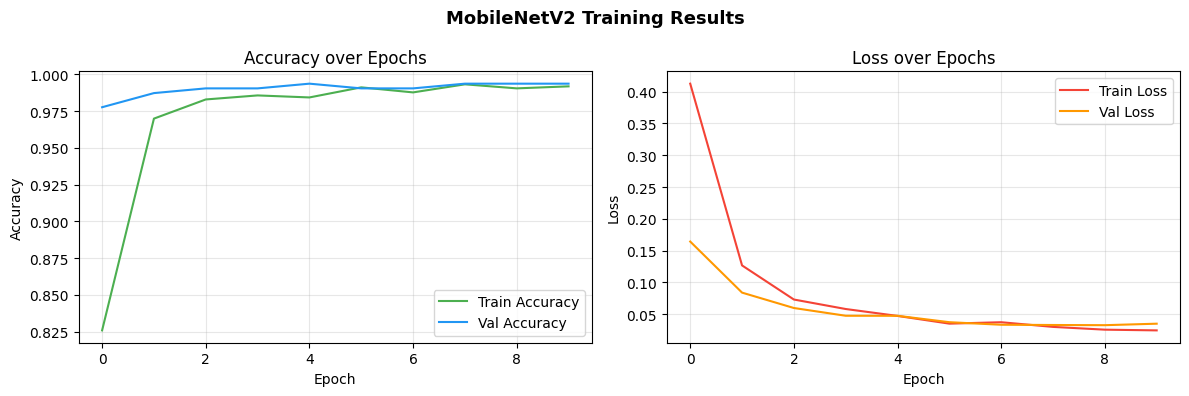

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('MobileNetV2 Training Results', fontsize=13, fontweight='bold')

# Accuracy
axes[0].plot(history.history['accuracy'],     label='Train Accuracy', color='#4CAF50')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy',   color='#2196F3')
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history['loss'],     label='Train Loss', color='#F44336')
axes[1].plot(history.history['val_loss'], label='Val Loss',   color='#FF9800')
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

# Save chart to results folder
os.makedirs('../results', exist_ok=True)
plt.savefig('../results/accuracy_loss.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
print('Evaluating on test set...')
test_loss, test_acc = model.evaluate(test_gen, verbose=1)

# Get best val accuracy from training
best_val_acc = max(history.history['val_accuracy'])

print('\n' + '='*50)
print('     FINAL RESULTS — MobileNetV2')
print('='*50)
print(f'  Train Accuracy  : {max(history.history["accuracy"])*100:.2f}%')
print(f'  Val Accuracy    : {best_val_acc*100:.2f}%')
print(f'  Test Accuracy   : {test_acc*100:.2f}%')
print(f'  Test Loss       : {test_loss:.4f}')

Evaluating on test set...
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 348ms/step - accuracy: 0.9841 - loss: 0.0516

     FINAL RESULTS — MobileNetV2
  Train Accuracy  : 99.31%
  Val Accuracy    : 99.36%
  Test Accuracy   : 98.41%
  Test Loss       : 0.0516
